Проведите всесторонний анализ и визуализацию данных. Пользуйтесь
https://cloud.mail.ru/public/A8ie/9dJHy8iHo, материалами лекции и другими доступными
источниками.

1. Используя ресурс kaggle (https://www.kaggle.com/), выберите один из наборов
данных. Загрузите этот набор и выведите первые 10 записей на экран.

In [49]:
import pandas as pd

df = pd.read_csv('adult.csv', sep=',', na_values='?')
print(df.iloc[0:10, 0:])

   age    workclass  fnlwgt     education  education.num marital.status  \
0   90          NaN   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66          NaN  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                NaN   Not-in-family  White  Female             0   
1    Exec-managerial   Not-in-family

2. Опишите данные набора: какие признаки в нем присутствуют, что они означают,
какой у них тип данных, какие значения могут принимать.

In [50]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [51]:
df.shape

(32561, 15)

In [52]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

3. Укажите какие признаки являются количественными, качественными порядковыми
и качественными номинальными

In [53]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Количественные признаки:", numeric_cols)


Количественные признаки: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


In [54]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Качественные признаки:", categorical_cols)


Качественные признаки: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


In [55]:
# Порядковые признаки (известны заранее)
ordinal_cols = ['education']

# Номинальные признаки — все остальные категориальные
nominal_cols = list(set(categorical_cols) - set(ordinal_cols))

print("Порядковые признаки:", ordinal_cols)
print("Номинальные признаки:", nominal_cols)



Порядковые признаки: ['education']
Номинальные признаки: ['sex', 'workclass', 'occupation', 'native.country', 'relationship', 'race', 'marital.status', 'income']


4. Рассчитайте параметры описательной статистики для признаков набора. С помощью
параметров описательной статистики опишите один из количественных признаков и
один из категориальных признаков. Есть ли в количественном признаке выбросы?
Какое значение является выбросом и почему? По какому категориальному признаку
можно группировать данные? Какие группировки представляют интерес и почему?

In [58]:
df['age'].describe()

count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [59]:
df['age'].isna().sum()

np.int64(0)

 Есть ли в количественном признаке выбросы?
Какое значение является выбросом и почему?

По межквартильному размаху (IQR) <br>
Определяем границы "обычных" значений: <br>
Всё, что меньше нижней границы или больше верхней, считается выбросом:

In [64]:
import numpy as np
q75, q25 = np.percentile(df['age'],
[75,25])
iqr = q75 - q25
print('IDR:', iqr)
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print(outliers)


IDR: 20.0
       age         workclass  fnlwgt  education  education.num  \
0       90               NaN   77053    HS-grad              9   
1       82           Private  132870    HS-grad              9   
118     83      Self-emp-inc  153183  Bachelors             13   
128     81           Private  177408    HS-grad              9   
199     90           Private   51744    HS-grad              9   
...    ...               ...     ...        ...            ...   
31939   82  Self-emp-not-inc   71438    HS-grad              9   
32305   90           Private  313749    HS-grad              9   
32468   85           Private   98611  Bachelors             13   
32500   82               NaN  403910    HS-grad              9   
32528   81               NaN  120478  Assoc-voc             11   

           marital.status       occupation   relationship   race     sex  \
0                 Widowed              NaN  Not-in-family  White  Female   
1                 Widowed  Exec-managerial  N

По какому категориальному признаку
можно группировать данные? Какие группировки представляют интерес и почему?

Примеры полезных группировок:

### По sex (пол)

Можно сравнить средний доход, рабочие часы, прирост капитала между мужчинами и женщинами.

Выявляет гендерные различия.

### По education или education.num

Позволяет увидеть, как уровень образования влияет на доход, рабочие часы, капитал.

Это логичная порядковая группировка.

### По occupation (профессия)

Можно увидеть, какие профессии приносят больше дохода или больше рабочие часы.

Полезно для экономического анализа и сегментации.

In [65]:
education_hours = df.groupby('education')['hours.per.week'].mean()
print(education_hours)


education
10th            37.052519
11th            33.925957
12th            35.780600
1st-4th         38.255952
5th-6th         38.897898
7th-8th         39.366873
9th             38.044747
Assoc-acdm      40.504217
Assoc-voc       41.610709
Bachelors       42.614006
Doctorate       46.973366
HS-grad         40.575374
Masters         43.836332
Preschool       36.647059
Prof-school     47.425347
Some-college    38.852284
Name: hours.per.week, dtype: float64


In [66]:
income_rate = df.groupby('sex')['income'].apply(lambda x: (x=='>50K').mean())
print(income_rate)


sex
Female    0.109461
Male      0.305737
Name: income, dtype: float64


5. Постройте графики для количественных и категориальных признаков. Какие
визуализации построены для количественных признаков? Какие особенности
распределения данных они позволяют наблюдать? Какие визуализации построены
для категориальных признаков? Какие особенности распределения данных они
позволяют наблюдать? Какие визуализации построены для пар признаков? Какие
особенности распределения данных они позволяют наблюдать?

Визуализация качественных признаков

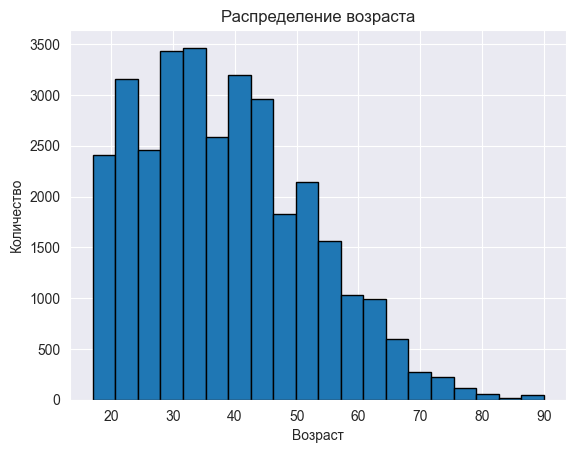

In [73]:
import matplotlib.pyplot as plt

df['age'].hist(bins=20, edgecolor='black')
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()


<Axes: xlabel='age', ylabel='income'>

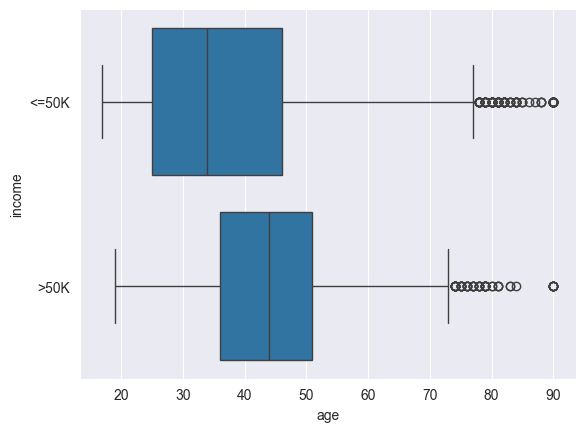

In [67]:
import seaborn as sns
sns.boxplot(data=df, x='age', y='income')

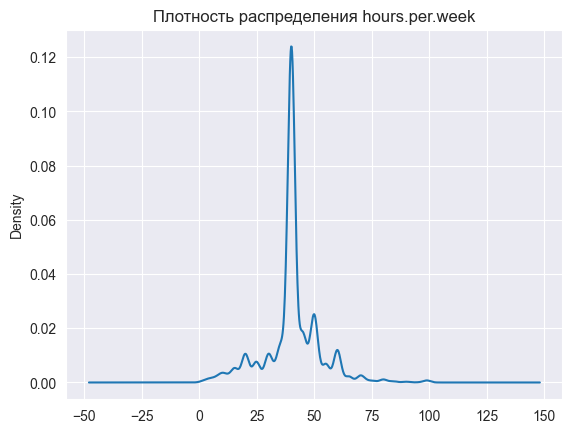

In [76]:
df['hours.per.week'].plot(kind='density')
plt.title('Плотность распределения hours.per.week')
plt.show()


Визуализация категориальных признаков

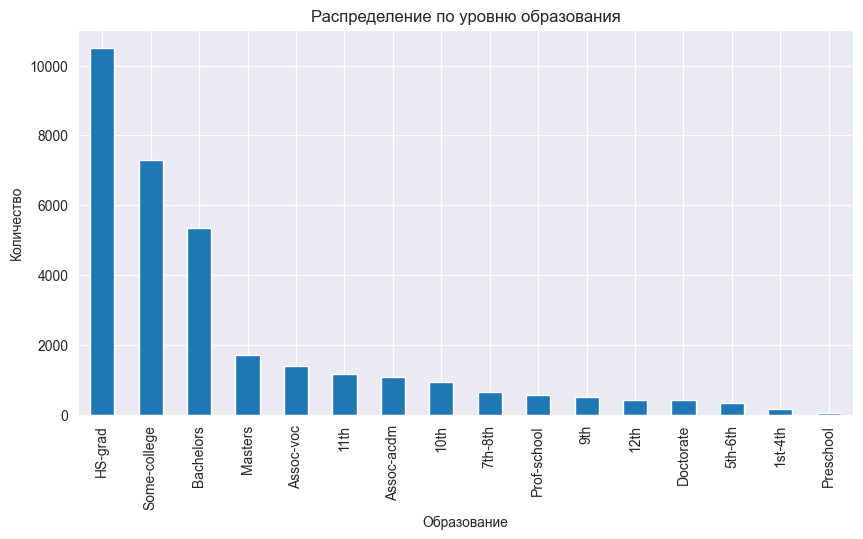

In [77]:
df['education'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Распределение по уровню образования')
plt.xlabel('Образование')
plt.ylabel('Количество')
plt.show()


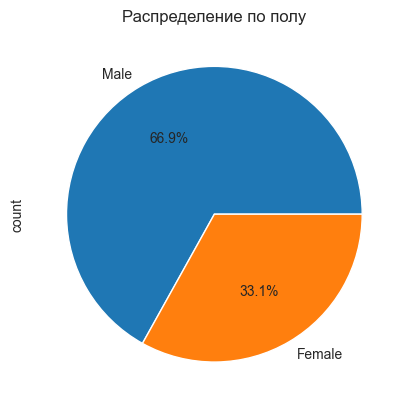

In [79]:
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Распределение по полу')
plt.show()


Визуализация пар признаков

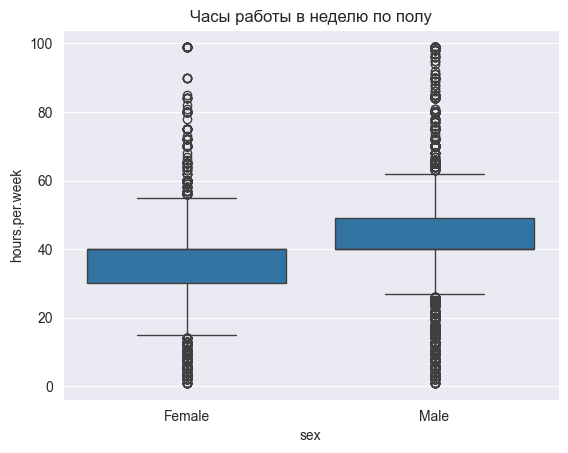

In [80]:
sns.boxplot(x='sex', y='hours.per.week', data=df)
plt.title('Часы работы в неделю по полу')
plt.show()


Что показывает:

распределение количественного признака внутри каждой категории

медиану, разброс и выбросы

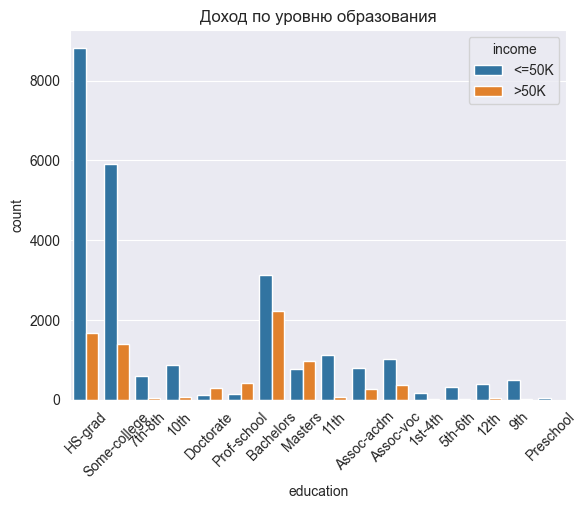

In [82]:
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title('Доход по уровню образования')
plt.show()


Что показывает:

как распределены категории по другой категориальной переменной

можно сравнить группы

6. Проведите корреляционный анализ. Есть ли в вашем наборе данных коррелирующие
признаки?

                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076646       0.036527      0.077674      0.057775   
fnlwgt         -0.076646  1.000000      -0.043195      0.000432     -0.010252   
education.num   0.036527 -0.043195       1.000000      0.122630      0.079923   
capital.gain    0.077674  0.000432       0.122630      1.000000     -0.031615   
capital.loss    0.057775 -0.010252       0.079923     -0.031615      1.000000   
hours.per.week  0.068756 -0.018768       0.148123      0.078409      0.054256   

                hours.per.week  
age                   0.068756  
fnlwgt               -0.018768  
education.num         0.148123  
capital.gain          0.078409  
capital.loss          0.054256  
hours.per.week        1.000000  


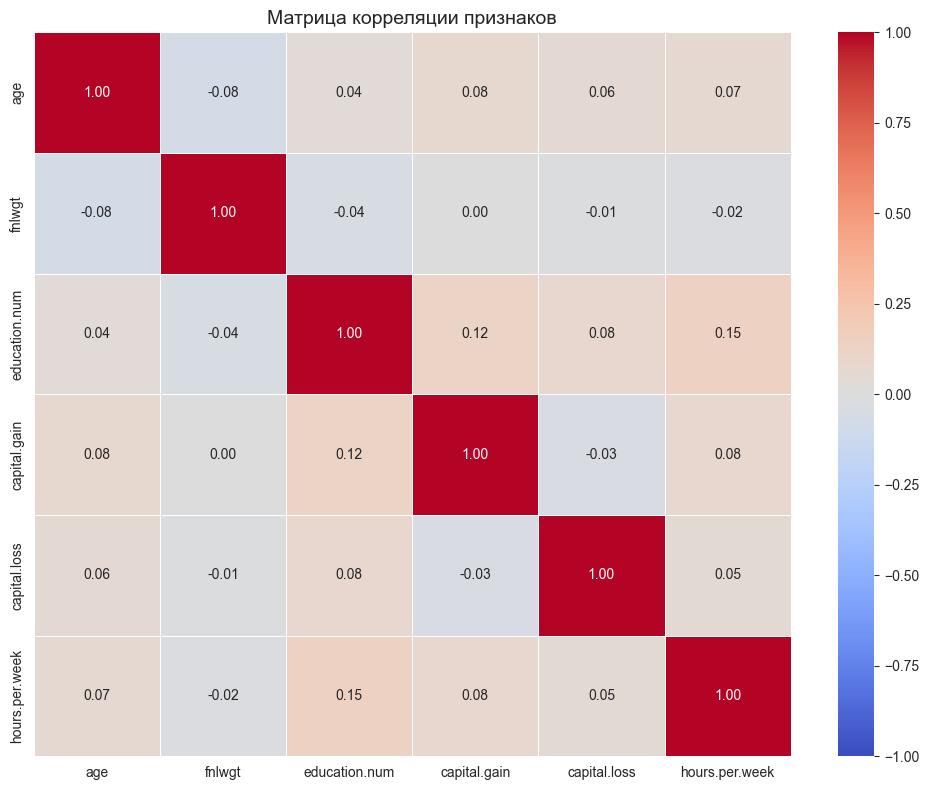

In [87]:
df_new = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = df_new.corr()
print(correlation_matrix)

# Создаем тепловую карту
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(correlation_matrix,
annot=True, # Отображение значений корреляции
cmap='coolwarm', # Цветовая схема
vmin=-1, vmax=1, # Диапазон значений
linewidths=0.5, # Толщина разделительных линий
fmt='.2f') # Формат чисел (2 знака после запятой)


plt.title('Матрица корреляции признаков', fontsize=14)
plt.tight_layout()
plt.show()

Сильных линейных корреляций между количественными признаками нет.

Слабые положительные корреляции:

education.num ↔ hours.per.week (0.148) — люди с более высоким образованием немного чаще работают больше часов.

education.num ↔ capital.gain (0.123) — небольшой тренд: более образованные чаще получают прирост капитала.

Остальные признаки практически не коррелируют (fnlwgt, capital.loss, age) между собой.